# 05 · Can a hybrid catch more unseen attacks?

**Question.** Does alerting when either a supervised model or an anomaly model fires catch more
attacks than either alone, by the success criteria fixed before any run?

The hybrid splits the 1% alert budget between the two models. The anomaly partner (Isolation Forest
or autoencoder) and the split are chosen on validation data only. The criteria, from the design doc:

1. Higher recall than the best single model on folds 2017_B, 2017_C and the 2018 new-family fold, in
   every seed. (Fold 2017_A has no supervised model, so no hybrid.)
2. Actual test false positive rate at most 1.5% on every fold and seed.
3. No attack family drops to zero that a single model caught.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"
summary = load_summary()

crit = summary["success_criteria"]
passed = [h for h, r in crit.items() if r["overall_pass"]]
print("Finding: " + (f"{', '.join(passed)} met every criterion." if passed else
      "no hybrid met the success criteria; the README reports the best single model instead."))
for h, r in crit.items():
    c1 = r["criterion_1_beats_best_single"]["runs"]
    wins = sum(x["pass"] for x in c1)
    print(f"  {NAMES[h]}: beat the best single model in {wins} of {len(c1)} criterion runs; "
          f"worst actual FPR {r['criterion_2_fpr_at_most_1.5pct']['worst_fpr']:.2%}; "
          f"families lost: {len(r['criterion_3_no_family_lost']['families_lost'])}.")


Finding: no hybrid met the success criteria; the README reports the best single model instead.
  Hybrid: LightGBM + anomaly model: beat the best single model in 0 of 15 criterion runs; worst actual FPR 99.43%; families lost: 11.
  Hybrid: log. regression + anomaly model: beat the best single model in 0 of 15 criterion runs; worst actual FPR 61.54%; families lost: 13.


In [2]:
crit = summary["success_criteria"]
pd.DataFrame({h: {"1. beats best single model": r["criterion_1_beats_best_single"]["pass"],
                  "2. actual FPR <= 1.5%": r["criterion_2_fpr_at_most_1.5pct"]["pass"],
                  "worst actual FPR": round(r["criterion_2_fpr_at_most_1.5pct"]["worst_fpr"], 4),
                  "3. no family lost": r["criterion_3_no_family_lost"]["pass"],
                  "overall": r["overall_pass"]} for h, r in crit.items()}).T

,1. beats best single model,2. actual FPR <= 1.5%,worst actual FPR,3. no family lost,overall
lgbm+anomaly,False,False,0.9943,False,False
logreg+anomaly,False,False,0.6154,False,False


In [3]:
# Criterion 1, run by run: hybrid recall vs the best single model on the same fold and seed
rows = []
for h, r in crit.items():
    for run in r["criterion_1_beats_best_single"]["runs"]:
        rows.append({"detector": NAMES[h], "fold": run["fold"], "seed": run["seed"],
                     "hybrid recall": run["hybrid"], "best single-model recall": run["best_single"]})
pd.DataFrame(rows).pivot_table(index=["detector", "fold"], values=["hybrid recall", "best single-model recall"],
                               aggfunc="median").round(3)

best single-model recall  hybrid recall
detector                                fold                                                        
Hybrid: LightGBM + anomaly model        2017_B                                  0.820          0.008
                                        2017_C                                  0.430          0.253
                                        2018_new_family_bot                     0.002          0.000
Hybrid: log. regression + anomaly model 2017_B                                  0.820          0.055
                                        2017_C                                  0.430          0.289
                                        2018_new_family_bot                     0.002          0.001

In [4]:
# Budget split chosen on validation (share of the 1% budget given to the supervised model), per seed
pd.DataFrame({f: {h: s for h, s in d.get("hybrid_shares_chosen", {}).items()}
              for f, d in summary["folds"].items() if d.get("hybrid_shares_chosen")}).T

,lgbm+anomaly,logreg+anomaly
2017_B,"[0.0, 0.0, 0.0, 0.0, 0.0]","[0.25, 0.25, 0.25, 0.25, 0.25]"
2017_C,"[0.25, 0.5, 0.75, 0.75, 0.75]","[0.0, 0.5, 0.5, 0.25, 0.0]"
2017_to_2018,"[1.0, 1.0, 1.0, 0.75, 0.75]","[1.0, 1.0, 1.0, 1.0, 1.0]"
2018_new_family_bot,"[1.0, 1.0, 0.5, 0.75, 1.0]","[0.75, 0.75, 0.25, 0.5, 0.5]"
2018_new_tool_ddos,"[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 0.75, 0.75, 0.75]"
2018_new_tool_dos,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.75, 1.0, 1.0, 1.0, 0.25]"
2018_same_attack_infiltration,"[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0, 1.0]"
2018_same_attack_web,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.75, 0.75, 1.0, 1.0, 0.75]"


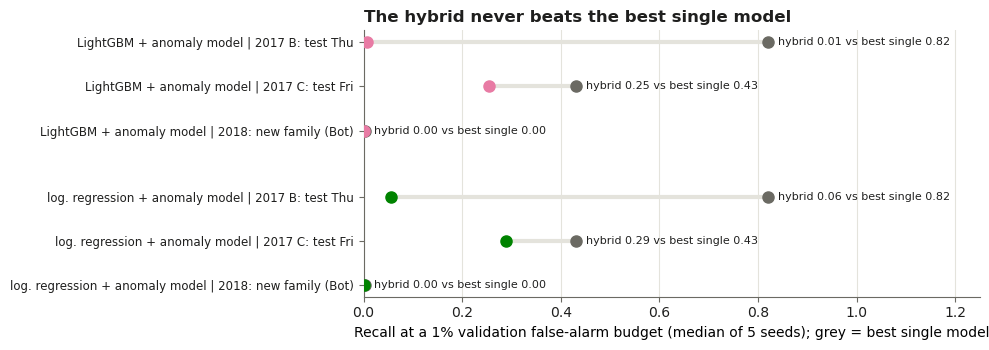

In [5]:
# Hybrid vs the best single model on the criterion folds (median over seeds, 1% budget)
labels = {"2017_B": "2017 B: test Thu", "2017_C": "2017 C: test Fri", "2018_new_family_bot": "2018: new family (Bot)"}
fig, ax = plt.subplots(figsize=(10, 3.6))
y = 0
ticks = []
for h in crit:
    runs = pd.DataFrame(crit[h]["criterion_1_beats_best_single"]["runs"])
    for fold, label in labels.items():
        r = runs[runs.fold == fold]
        hyb, single = r["hybrid"].median(), r["best_single"].median()
        ax.plot([hyb, single], [y, y], color="#e4e3dc", linewidth=3, zorder=1)
        ax.plot(single, y, "o", color=MUTED, markersize=8, zorder=2)
        ax.plot(hyb, y, "o", color=COLORS[h], markersize=8, zorder=3)
        ax.text(max(hyb, single) + 0.02, y, f"hybrid {hyb:.2f} vs best single {single:.2f}", va="center", fontsize=8, color=INK)
        ticks.append((y, f"{NAMES[h].replace('Hybrid: ', '')} | {label}"))
        y += 1
    y += 0.5
ax.set_yticks([t for t, _ in ticks]); ax.set_yticklabels([l for _, l in ticks], fontsize=8.5); ax.invert_yaxis()
ax.set_xlim(0, 1.25); ax.set_xlabel("Recall at a 1% validation false-alarm budget (median of 5 seeds); grey = best single model")
wins = sum(x["pass"] for h in crit for x in crit[h]["criterion_1_beats_best_single"]["runs"])
total = sum(len(crit[h]["criterion_1_beats_best_single"]["runs"]) for h in crit)
ax.set_title("The hybrid never beats the best single model" if wins == 0 else
             f"The hybrid beats the best single model in {wins} of {total} runs", loc="left", fontweight="bold", color=INK)
style(ax); fig.tight_layout(); plt.show()

## What this shows

The hybrid fails all three criteria.

- **The validation day points the wrong way.** On fold 2017_B the validation day (Wednesday, DoS)
  rewards the autoencoder, so the hybrid gives it the whole budget; the test day (Thursday, web)
  rewards LightGBM. Choosing settings on one unseen family does not carry over to another.
- **Anomaly models bring their drift with them.** Whenever the hybrid leans on Isolation Forest or
  the autoencoder, it inherits their broken false-alarm budgets on new days.
- **Families get lost.** Splitting the budget leaves each model too few alerts, so families that
  a single model caught fall to zero (web attacks on 2017_B, Bot on 2017_C).

The earlier informal result that suggested a gain (recall 0.675 on Wed+Thu) picked its budget
split after looking at the test days. With the split chosen on validation data only, the gain does
not appear. Per the design, the README reports the best single model instead.

## Limits

The hybrid is one simple combination rule. A learned combination might do better, but it would
need validation data that represents unseen attacks, which is the very thing this data cannot
supply.